In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
df = pd.read_csv("../data/processed/olist_orders_abt.csv")

df.head()

,order_id,customer_id,customer_unique_id,customer_city,customer_state,order_status,order_year,order_month,order_day,order_day_of_week,...,total_payment_value,max_payment_installments,payment_types_count,dominant_payment_type,total_items,total_price,total_freight,unique_products,unique_sellers,main_product_category
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,delivered,2017,10,2,0,...,38.71,1.0,2.0,voucher,1.0,29.99,8.72,1.0,1.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,barreiras,BA,delivered,2018,7,24,1,...,141.46,1.0,1.0,boleto,1.0,118.70,22.76,1.0,1.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,delivered,2018,8,8,2,...,179.12,3.0,1.0,credit_card,1.0,159.90,19.22,1.0,1.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,delivered,2017,11,18,5,...,72.20,1.0,1.0,credit_card,1.0,45.00,27.20,1.0,1.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,delivered,2018,2,13,1,...,28.62,1.0,1.0,credit_card,1.0,19.90,8.72,1.0,1.0,stationery


In [3]:
df.shape

(99441, 29)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   order_id                  99441 non-null  str    
 1   customer_id               99441 non-null  str    
 2   customer_unique_id        99441 non-null  str    
 3   customer_city             99441 non-null  str    
 4   customer_state            99441 non-null  str    
 5   order_status              99441 non-null  str    
 6   order_year                99441 non-null  int64  
 7   order_month               99441 non-null  int64  
 8   order_day                 99441 non-null  int64  
 9   order_day_of_week         99441 non-null  int64  
 10  order_hour                99441 non-null  int64  
 11  delivery_days             96476 non-null  float64
 12  estimated_delivery_days   99441 non-null  float64
 13  delivery_delay_days       96476 non-null  float64
 14  is_late_delivery 

In [5]:
df.describe()

,order_year,order_month,order_day,order_day_of_week,order_hour,delivery_days,estimated_delivery_days,delivery_delay_days,is_late_delivery,review_score,...,review_comment_count,has_review_comment,total_payment_value,max_payment_installments,payment_types_count,total_items,total_price,total_freight,unique_products,unique_sellers
count,99441.000000,99441.000000,99441.000000,99441.000000,99441.000000,96476.000000,99441.000000,96476.000000,99441.000000,98673.000000,...,98673.000000,98673.000000,99440.000000,99440.000000,99440.000000,98666.000000,98666.000000,98666.000000,98666.000000,98666.000000
mean,2017.539838,6.032220,15.505948,2.755735,14.770829,12.558702,23.767650,-11.179120,0.078710,4.086793,...,0.415281,0.413852,160.990267,2.930521,1.022586,1.141731,137.754076,22.823562,1.038098,1.013622
std,0.505007,3.232999,8.667298,1.966495,5.326800,9.546530,8.832371,10.186113,0.269287,1.346274,...,0.495685,0.492525,221.951257,2.715685,0.148582,0.538452,210.645145,21.650909,0.226456,0.122297
min,2016.000000,1.000000,1.000000,0.000000,0.000000,0.533414,1.648993,-146.016123,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.850000,0.000000,1.000000,1.000000
25%,2017.000000,3.000000,8.000000,1.000000,11.000000,6.766403,18.331690,-16.244384,0.000000,4.000000,...,0.000000,0.000000,62.010000,1.000000,1.000000,1.000000,45.900000,13.850000,1.000000,1.000000
50%,2018.000000,6.000000,15.000000,3.000000,15.000000,10.217755,23.240370,-11.948941,0.000000,5.000000,...,0.000000,0.000000,105.290000,2.000000,1.000000,1.000000,86.900000,17.170000,1.000000,1.000000
75%,2018.000000,8.000000,23.000000,4.000000,19.000000,15.720327,28.424861,-6.390000,0.000000,5.000000,...,1.000000,1.000000,176.970000,4.000000,1.000000,1.000000,149.900000,24.040000,1.000000,1.000000
max,2018.000000,12.000000,31.000000,6.000000,23.000000,209.628611,155.135463,188.975081,1.000000,5.000000,...,3.000000,1.000000,13664.080000,24.000000,2.000000,21.000000,13440.000000,1794.960000,8.000000,5.000000


In [6]:
nominal_columns = [
    "customer_state",
    "customer_city",
    "main_product_category",
    "dominant_payment_type",
    "order_status"
]

ordinal_columns = [
    "review_score"
]

interval_columns = [
    "order_hour",
    "order_month",
    "order_day_of_week"
]

ratio_columns = [
    "total_payment_value",
    "total_price",
    "total_freight",
    "delivery_days",
    "estimated_delivery_days",
    "delivery_delay_days",
    "total_items",
    "unique_products",
    "unique_sellers"
]

In [7]:
def keep_existing_columns(dataframe, columns):
    return [col for col in columns if col in dataframe.columns]

nominal_columns = keep_existing_columns(df, nominal_columns)
ordinal_columns = keep_existing_columns(df, ordinal_columns)
interval_columns = keep_existing_columns(df, interval_columns)
ratio_columns = keep_existing_columns(df, ratio_columns)

print("Nominal:", nominal_columns)
print("Ordinal:", ordinal_columns)
print("Interval:", interval_columns)
print("Ratio:", ratio_columns)

Nominal: ['customer_state', 'customer_city', 'main_product_category', 'dominant_payment_type', 'order_status']
Ordinal: ['review_score']
Interval: ['order_hour', 'order_month', 'order_day_of_week']
Ratio: ['total_payment_value', 'total_price', 'total_freight', 'delivery_days', 'estimated_delivery_days', 'delivery_delay_days', 'total_items', 'unique_products', 'unique_sellers']


In [8]:
if "delivery_days" in df.columns:
    df["delivery_speed_category"] = pd.cut(
        df["delivery_days"],
        bins=[-1, 7, 15, 30, np.inf],
        labels=["Fast", "Normal", "Slow", "VeryDelayed"]
    )

df[["delivery_days", "delivery_speed_category"]].head()

,delivery_days,delivery_speed_category
0,8.436574,Normal
1,13.782037,Normal
2,9.394213,Normal
3,13.208750,Normal
4,2.873877,Fast


In [9]:
if "total_payment_value" in df.columns:
    df["payment_value_band"] = pd.qcut(
        df["total_payment_value"],
        q=4,
        labels=["Low", "Medium", "High", "Premium"],
        duplicates="drop"
    )

df[["total_payment_value", "payment_value_band"]].head()

,total_payment_value,payment_value_band
0,38.71,Low
1,141.46,High
2,179.12,Premium
3,72.20,Medium
4,28.62,Low


In [10]:
df.isnull().sum()

order_id                       0
customer_id                    0
customer_unique_id             0
customer_city                  0
customer_state                 0
order_status                   0
order_year                     0
order_month                    0
order_day                      0
order_day_of_week              0
order_hour                     0
delivery_days               2965
estimated_delivery_days        0
delivery_delay_days         2965
is_late_delivery               0
review_score                 768
is_low_review                  0
review_comment_count         768
has_review_comment           768
total_payment_value            1
max_payment_installments       1
payment_types_count            1
dominant_payment_type          1
total_items                  775
total_price                  775
total_freight                775
unique_products              775
unique_sellers               775
main_product_category       2185
delivery_speed_category     2965
payment_va

In [11]:
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": (df.isnull().sum() / len(df)) * 100
}).sort_values(
    by="missing_percent",
    ascending=False
)

missing_summary.head(20)

,missing_count,missing_percent
delivery_delay_days,2965,2.981668
delivery_days,2965,2.981668
delivery_speed_category,2965,2.981668
main_product_category,2185,2.197283
total_price,775,0.779357
unique_sellers,775,0.779357
total_freight,775,0.779357
total_items,775,0.779357
unique_products,775,0.779357
review_score,768,0.772317


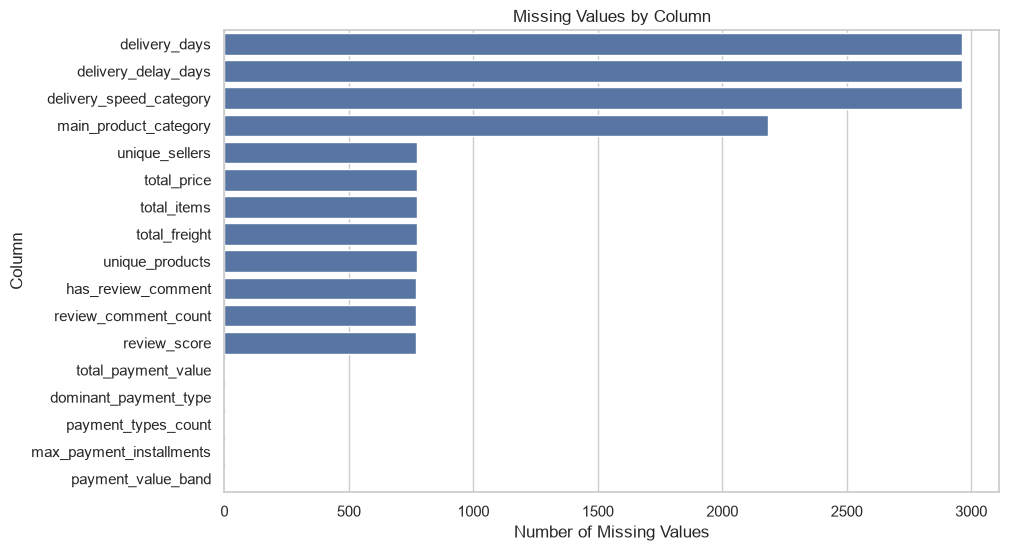

In [12]:
missing_values = df.isnull().sum()

missing_values = missing_values[
    missing_values > 0
].sort_values(ascending=False)

sns.barplot(
    x=missing_values.values,
    y=missing_values.index
)

plt.title("Missing Values by Column")
plt.xlabel("Number of Missing Values")
plt.ylabel("Column")
plt.show()

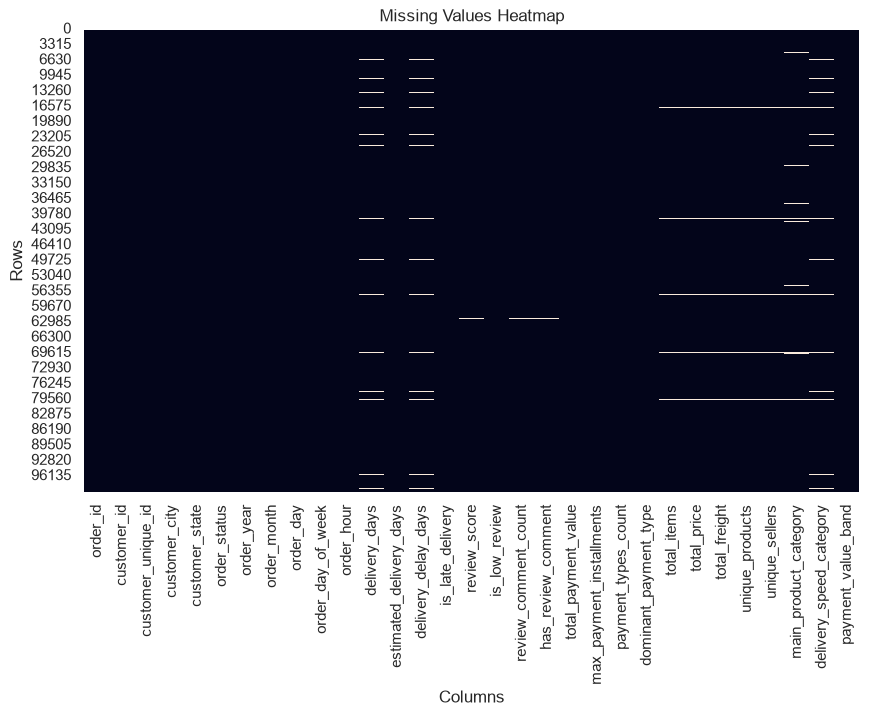

In [13]:
sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

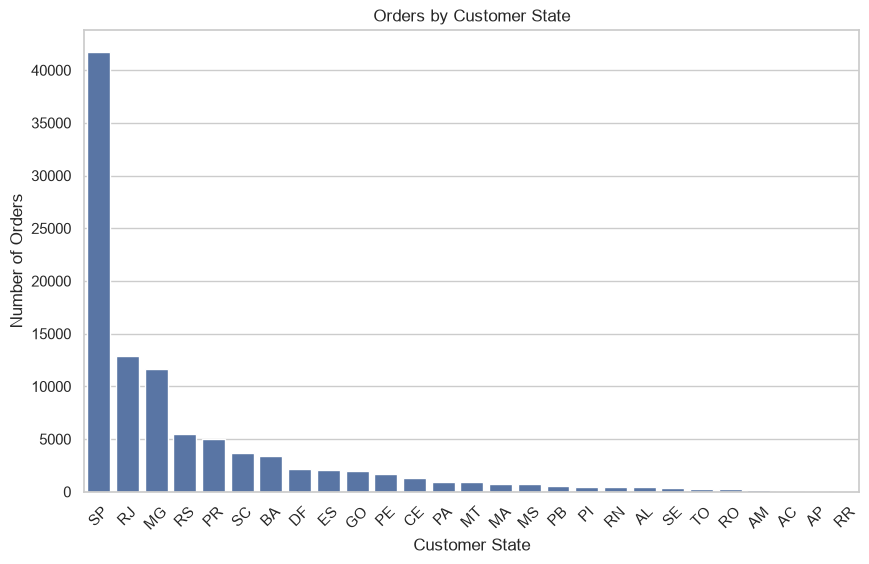

In [14]:
if "customer_state" in df.columns:
    sns.countplot(
        data=df,
        x="customer_state",
        order=df["customer_state"].value_counts().index
    )

    plt.title("Orders by Customer State")
    plt.xlabel("Customer State")
    plt.ylabel("Number of Orders")
    plt.xticks(rotation=45)
    plt.show()

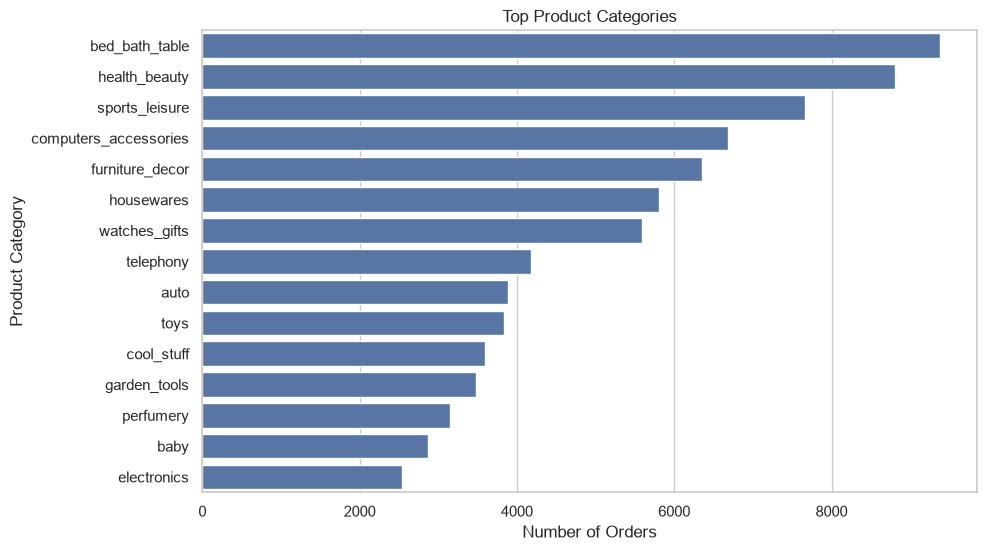

In [15]:
if "main_product_category" in df.columns:
    top_categories = (
        df["main_product_category"]
        .value_counts()
        .head(15)
        .index
    )

    sns.countplot(
        data=df[df["main_product_category"].isin(top_categories)],
        y="main_product_category",
        order=top_categories
    )

    plt.title("Top Product Categories")
    plt.xlabel("Number of Orders")
    plt.ylabel("Product Category")
    plt.show()

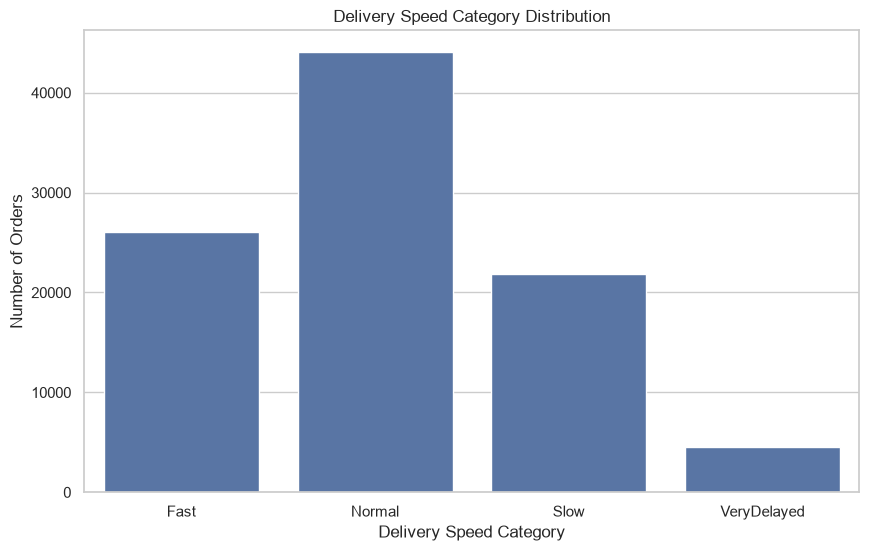

In [16]:
if "delivery_speed_category" in df.columns:
    delivery_order = [
        "Fast",
        "Normal",
        "Slow",
        "VeryDelayed"
    ]

    sns.countplot(
        data=df,
        x="delivery_speed_category",
        order=delivery_order
    )

    plt.title("Delivery Speed Category Distribution")
    plt.xlabel("Delivery Speed Category")
    plt.ylabel("Number of Orders")
    plt.show()

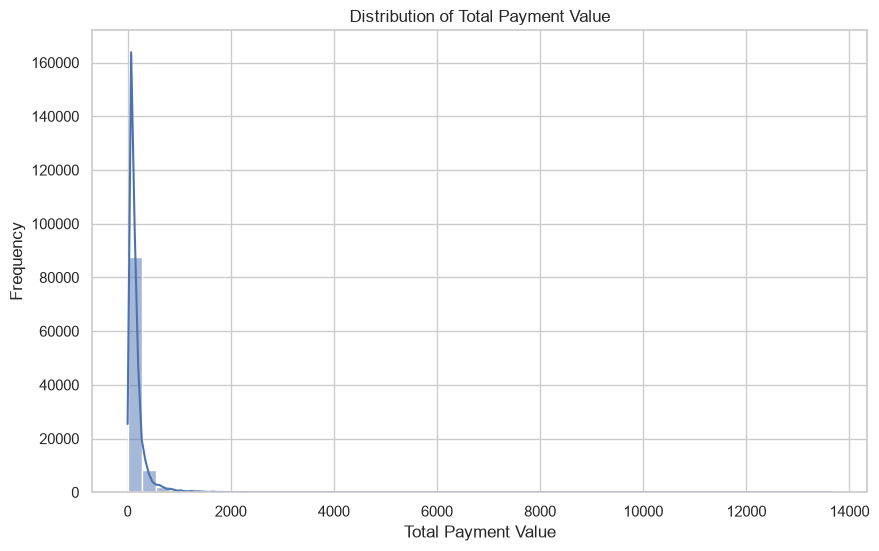

In [17]:
if "total_payment_value" in df.columns:
    sns.histplot(
        data=df,
        x="total_payment_value",
        bins=50,
        kde=True
    )

    plt.title("Distribution of Total Payment Value")
    plt.xlabel("Total Payment Value")
    plt.ylabel("Frequency")
    plt.show()

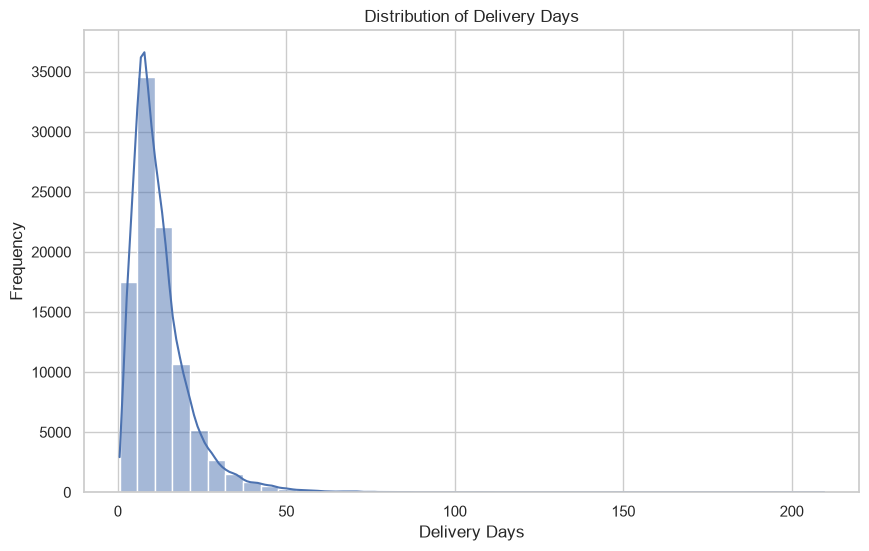

In [18]:
if "delivery_days" in df.columns:
    sns.histplot(
        data=df,
        x="delivery_days",
        bins=40,
        kde=True
    )

    plt.title("Distribution of Delivery Days")
    plt.xlabel("Delivery Days")
    plt.ylabel("Frequency")
    plt.show()

In [19]:
skew_cols = [
    "total_payment_value",
    "total_price",
    "total_freight",
    "delivery_days",
    "delivery_delay_days",
    "total_items"
]

skew_cols = keep_existing_columns(df, skew_cols)

skewness_values = (
    df[skew_cols]
    .skew()
    .sort_values(ascending=False)
)

skewness_values

total_freight          12.052723
total_price             9.727741
total_payment_value     9.150169
total_items             7.527006
delivery_days           3.832817
delivery_delay_days     2.009198
dtype: float64

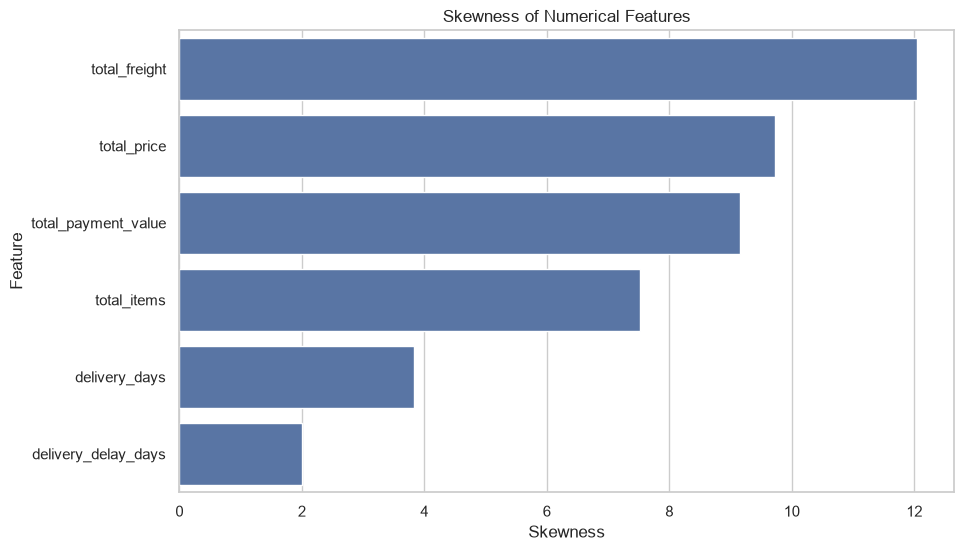

In [20]:
sns.barplot(
    x=skewness_values.values,
    y=skewness_values.index
)

plt.title("Skewness of Numerical Features")
plt.xlabel("Skewness")
plt.ylabel("Feature")
plt.show()

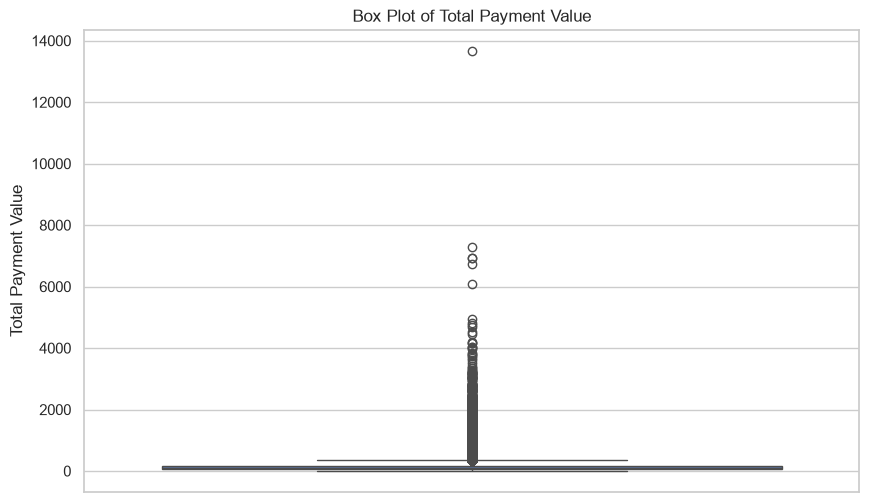

In [21]:
if "total_payment_value" in df.columns:
    sns.boxplot(
        data=df,
        y="total_payment_value"
    )

    plt.title("Box Plot of Total Payment Value")
    plt.ylabel("Total Payment Value")
    plt.show()

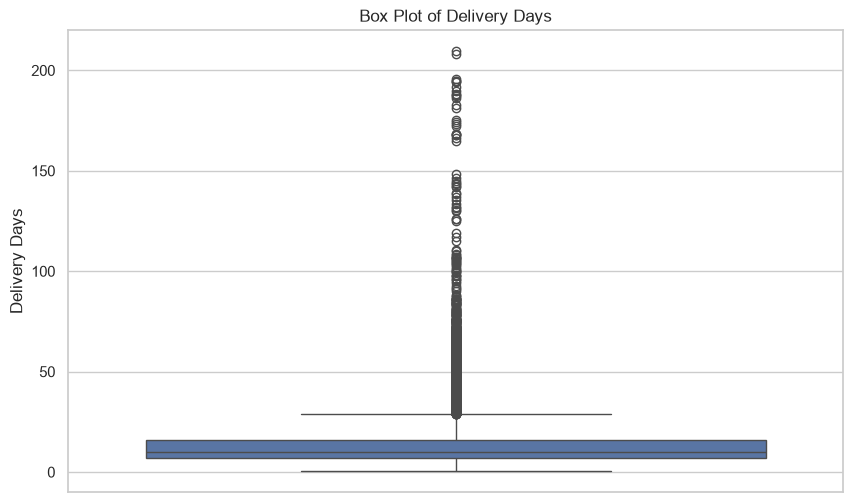

In [22]:
if "delivery_days" in df.columns:
    sns.boxplot(
        data=df,
        y="delivery_days"
    )

    plt.title("Box Plot of Delivery Days")
    plt.ylabel("Delivery Days")
    plt.show()

In [23]:
def iqr_outlier_summary(dataframe, column):
    q1 = dataframe[column].quantile(0.25)
    q3 = dataframe[column].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = dataframe[
        (dataframe[column] < lower_bound) |
        (dataframe[column] > upper_bound)
    ]

    summary = {
        "column": column,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": len(outliers),
        "outlier_percent": (len(outliers) / len(dataframe)) * 100
    }

    return summary

In [24]:
if "total_payment_value" in df.columns:
    print(iqr_outlier_summary(df, "total_payment_value"))

if "delivery_days" in df.columns:
    print(iqr_outlier_summary(df, "delivery_days"))

{'column': 'total_payment_value', 'q1': np.float64(62.01), 'q3': np.float64(176.97), 'iqr': np.float64(114.96000000000001), 'lower_bound': np.float64(-110.43), 'upper_bound': np.float64(349.40999999999997), 'outlier_count': 7866, 'outlier_percent': 7.910218119286813}
{'column': 'delivery_days', 'q1': np.float64(6.766403356481482), 'q3': np.float64(15.720326967592591), 'iqr': np.float64(8.953923611111108), 'lower_bound': np.float64(-6.66448206018518), 'upper_bound': np.float64(29.151212384259253), 'outlier_count': 4899, 'outlier_percent': 4.926539354994419}


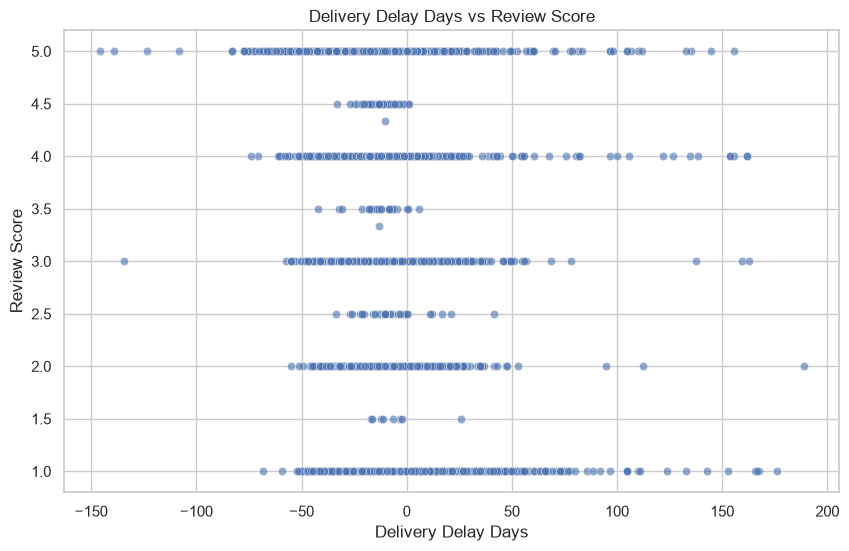

In [25]:
if {"delivery_delay_days", "review_score"}.issubset(df.columns):

    sns.scatterplot(
        data=df,
        x="delivery_delay_days",
        y="review_score",
        alpha=0.6
    )

    plt.title("Delivery Delay Days vs Review Score")
    plt.xlabel("Delivery Delay Days")
    plt.ylabel("Review Score")
    plt.show()

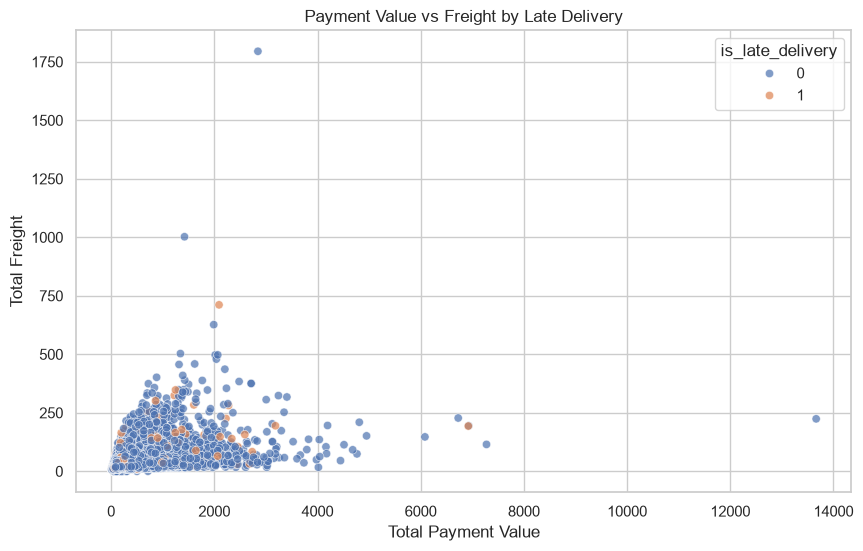

In [26]:
if {
    "total_payment_value",
    "total_freight",
    "is_late_delivery"
}.issubset(df.columns):

    sns.scatterplot(
        data=df,
        x="total_payment_value",
        y="total_freight",
        hue="is_late_delivery",
        alpha=0.7
    )

    plt.title("Payment Value vs Freight by Late Delivery")
    plt.xlabel("Total Payment Value")
    plt.ylabel("Total Freight")
    plt.show()

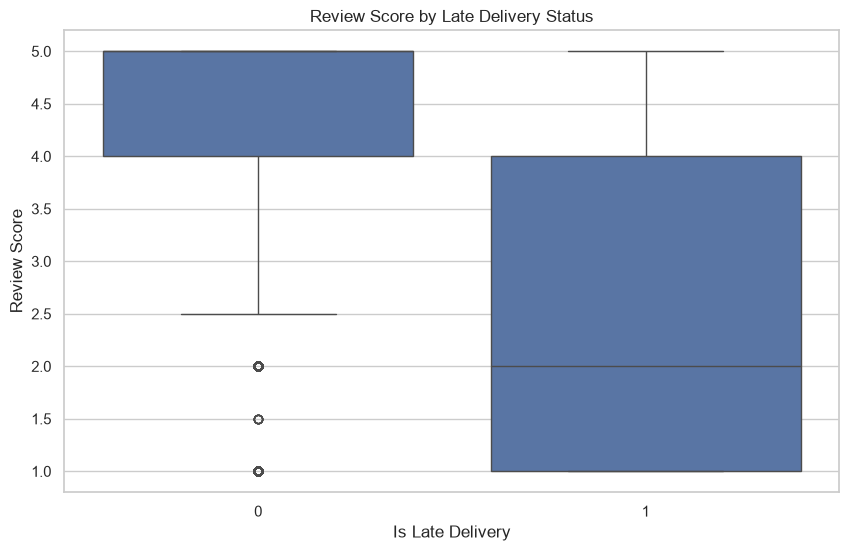

In [27]:
if {"is_late_delivery", "review_score"}.issubset(df.columns):

    sns.boxplot(
        data=df,
        x="is_late_delivery",
        y="review_score"
    )

    plt.title("Review Score by Late Delivery Status")
    plt.xlabel("Is Late Delivery")
    plt.ylabel("Review Score")
    plt.show()

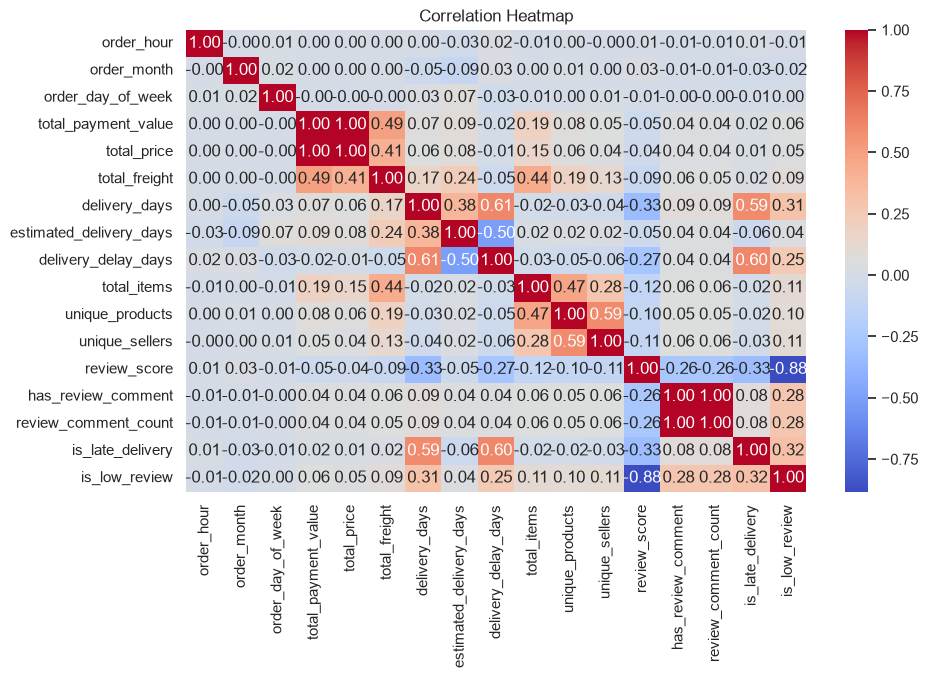

In [28]:
numeric_columns = [
    "order_hour",
    "order_month",
    "order_day_of_week",
    "total_payment_value",
    "total_price",
    "total_freight",
    "delivery_days",
    "estimated_delivery_days",
    "delivery_delay_days",
    "total_items",
    "unique_products",
    "unique_sellers",
    "review_score",
    "has_review_comment",
    "review_comment_count",
    "is_late_delivery",
    "is_low_review"
]

numeric_columns = keep_existing_columns(df, numeric_columns)

corr = df[numeric_columns].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

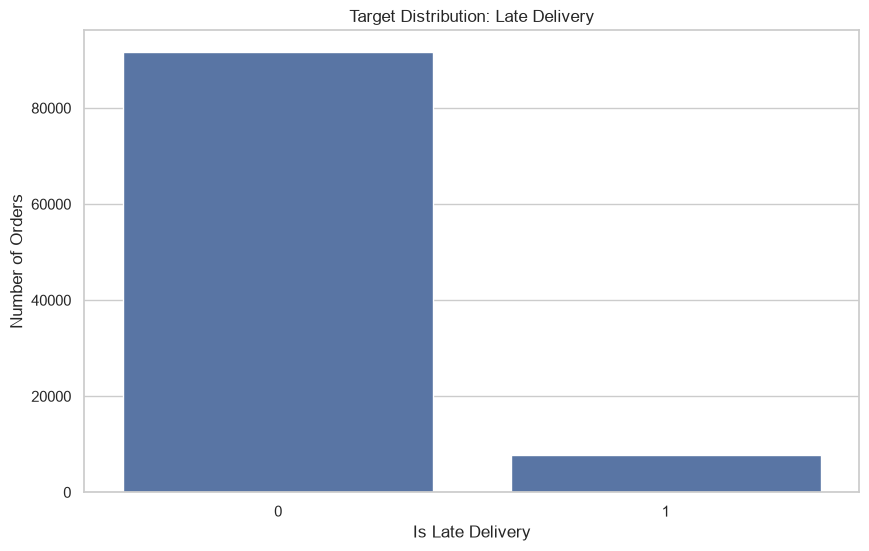

In [29]:
if "is_late_delivery" in df.columns:

    sns.countplot(
        data=df,
        x="is_late_delivery"
    )

    plt.title("Target Distribution: Late Delivery")
    plt.xlabel("Is Late Delivery")
    plt.ylabel("Number of Orders")
    plt.show()

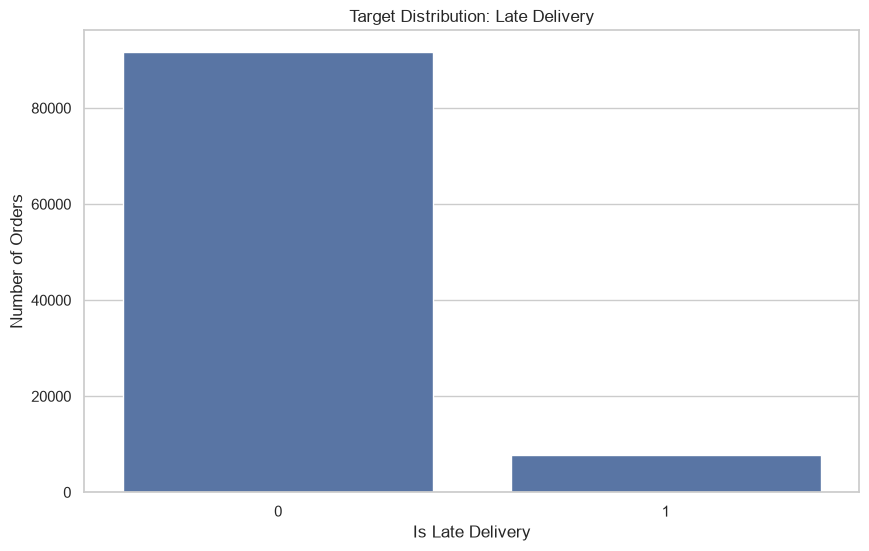

In [30]:
if "is_late_delivery" in df.columns:

    sns.countplot(
        data=df,
        x="is_late_delivery"
    )

    plt.title("Target Distribution: Late Delivery")
    plt.xlabel("Is Late Delivery")
    plt.ylabel("Number of Orders")
    plt.show()

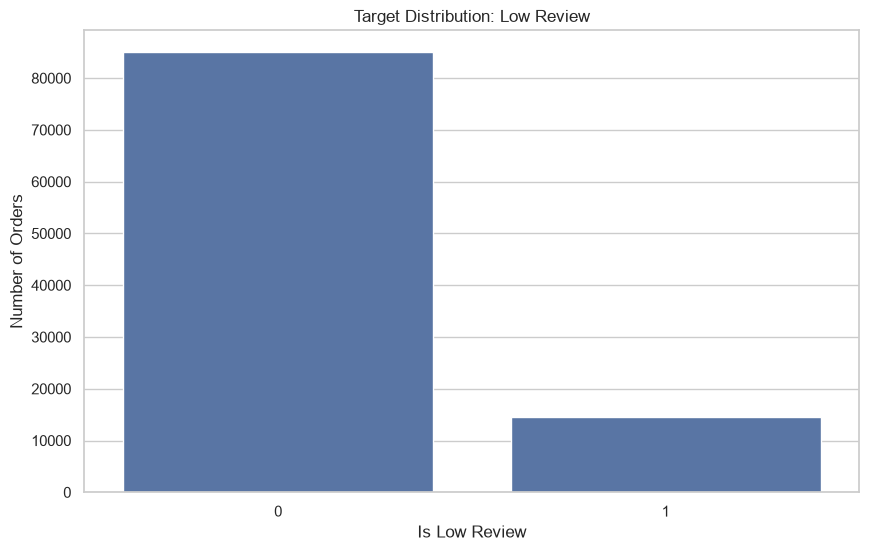

In [31]:
if "is_low_review" in df.columns:

    sns.countplot(
        data=df,
        x="is_low_review"
    )

    plt.title("Target Distribution: Low Review")
    plt.xlabel("Is Low Review")
    plt.ylabel("Number of Orders")
    plt.show()

In [2]:
def keep_existing_columns(dataframe, columns):
    return [col for col in columns if col in dataframe.columns]

In [7]:
import pandas as pd
import numpy as np

# Load Lab 2 ABT
df = pd.read_csv("../data/processed/olist_orders_abt.csv")

# Create a copy for cleaning
clean_df = df.copy()


# Helper function
def keep_existing_columns(dataframe, columns):
    return [col for col in columns if col in dataframe.columns]


# 1. Create missing delivery indicator
if "delivery_days" in clean_df.columns:
    clean_df["missing_delivery_days"] = (
        clean_df["delivery_days"].isnull().astype(int)
    )


# 2. Categorical columns
categorical_missing_cols = [
    "main_product_category",
    "dominant_payment_type",
    "delivery_speed_category",
    "payment_value_band",
    "customer_state",
    "customer_city",
    "order_status"
]

categorical_missing_cols = keep_existing_columns(
    clean_df,
    categorical_missing_cols
)


# 3. Fill categorical missing values
for col in categorical_missing_cols:
    clean_df[col] = (
        clean_df[col]
        .astype("object")
        .fillna("Unknown")
    )


# 4. Numerical columns
numerical_missing_cols = [
    "total_payment_value",
    "total_price",
    "total_freight",
    "delivery_days",
    "estimated_delivery_days",
    "delivery_delay_days",
    "total_items",
    "unique_products",
    "unique_sellers",
    "review_score"
]

numerical_missing_cols = keep_existing_columns(
    clean_df,
    numerical_missing_cols
)


# 5. Fill numerical missing values with median
for col in numerical_missing_cols:
    clean_df[col] = clean_df[col].fillna(
        clean_df[col].median()
    )


# 6. Check remaining missing values
remaining_missing = clean_df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]

print("Cleaning completed!")
print("\nRemaining missing values:")
print(remaining_missing)

Cleaning completed!

Remaining missing values:
review_comment_count        768
has_review_comment          768
max_payment_installments      1
payment_types_count           1
dtype: int64


In [8]:
# Log transformation for skewed numerical features

log_columns = [
    "total_payment_value",
    "total_freight",
    "total_price"
]

log_columns = [
    col for col in log_columns
    if col in clean_df.columns
]

for col in log_columns:
    clean_df[col + "_log"] = np.log1p(clean_df[col])

print("Log transformation completed!")
print("Transformed columns:")
print([col + "_log" for col in log_columns])

Log transformation completed!
Transformed columns:
['total_payment_value_log', 'total_freight_log', 'total_price_log']


In [9]:
clean_df[
    [col + "_log" for col in log_columns]
].head()

,total_payment_value_log,total_freight_log,total_price_log
0,3.681603,2.274186,3.433665
1,4.959061,3.168003,4.784989
2,5.193623,3.006672,5.080783
3,4.293195,3.339322,3.828641
4,3.388450,2.274186,3.039749


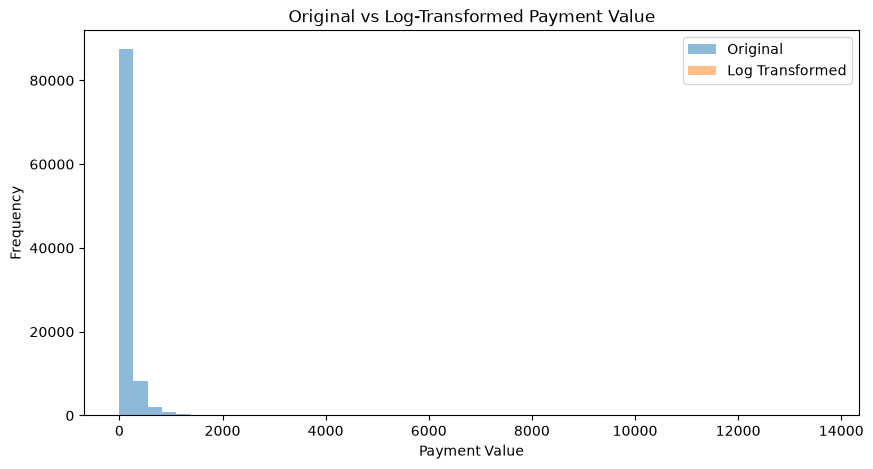

In [12]:
import matplotlib.pyplot as plt

# Compare original and log-transformed payment values

if "total_payment_value" in clean_df.columns and "total_payment_value_log" in clean_df.columns:

    plt.figure(figsize=(10, 5))

    plt.hist(
        clean_df["total_payment_value"],
        bins=50,
        alpha=0.5,
        label="Original"
    )

    plt.hist(
        clean_df["total_payment_value_log"],
        bins=50,
        alpha=0.5,
        label="Log Transformed"
    )

    plt.title("Original vs Log-Transformed Payment Value")
    plt.xlabel("Payment Value")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

else:
    print("Required columns are missing.")

ModuleNotFoundError: No module named 'sklearn'

In [14]:
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.4 MB ? eta -:--:--
   ------- -------------------------------- 1.6/8.4 MB 5.4 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.4 MB 7.0 MB/s eta 0:00:01
   ------------------------- -------------- 5.2/8.4 MB 8.2 MB/s eta 0:00:01
   ------------------------------------ --- 7.6/8.4 MB 8.3 MB/s eta 0:00:01
   ---------------------------------------- 8.4/8.4 MB 8.3 MB/s  0:00:01
   ---------------------------------------- 0.0/37.4 MB ? eta -:--:--
   - -------------------------------------- 1.6/37.4 MB 11.2 MB/s eta 0:00:04
   --- ------------------------------------ 3.4/37.4 MB 11.1 MB/s eta 0:00:04
   ------ --------------------------------- 6.0/37.4 MB 10.8 MB/s eta 0:00:03
   ------- -------------------------------- 7.3/37.4 MB 9.4 MB/s eta 0:00:04
   ---------- ------------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

In [17]:
# Scaling demonstration

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

scaling_columns = [
    "total_payment_value",
    "total_price",
    "total_freight",
    "delivery_days"
]

scaling_columns = [
    col for col in scaling_columns
    if col in clean_df.columns
]

# Make sure there are no missing values
scaling_data = clean_df[scaling_columns].copy()

# Standard Scaling
standard_scaler = StandardScaler()
standard_scaled = standard_scaler.fit_transform(scaling_data)

# Min-Max Scaling
minmax_scaler = MinMaxScaler()
minmax_scaled = minmax_scaler.fit_transform(scaling_data)

# Robust Scaling
robust_scaler = RobustScaler()
robust_scaled = robust_scaler.fit_transform(scaling_data)

# Convert results to DataFrames
standard_df = pd.DataFrame(
    standard_scaled,
    columns=[col + "_standard" for col in scaling_columns]
)

minmax_df = pd.DataFrame(
    minmax_scaled,
    columns=[col + "_minmax" for col in scaling_columns]
)

robust_df = pd.DataFrame(
    robust_scaled,
    columns=[col + "_robust" for col in scaling_columns]
)

print("Scaling completed!")
print("\nStandard Scaled:")
print(standard_df.head())

print("\nMin-Max Scaled:")
print(minmax_df.head())

print("\nRobust Scaled:")
print(robust_df.head())

Scaling completed!

Standard Scaled:
   total_payment_value_standard  total_price_standard  total_freight_standard  \
0                     -0.550936             -0.511593               -0.651748   
1                     -0.087992             -0.088902               -0.000904   
2                      0.081687              0.107411               -0.165006   
3                     -0.400045             -0.440073                0.204918   
4                     -0.596397             -0.559671               -0.651748   

   delivery_days_standard  
0               -0.430572  
1                0.137399  
2               -0.328820  
3                0.076486  
4               -1.021624  

Min-Max Scaled:
   total_payment_value_minmax  total_price_minmax  total_freight_minmax  \
0                    0.002833            0.002168              0.004858   
1                    0.010353            0.008769              0.012680   
2                    0.013109            0.011835              0.0

In [18]:
# Data Leakage Check

target = "is_late_delivery"

leakage_columns = [
    "delivery_delay_days",
    "delivery_speed_category",
    "delivery_days"
]

leakage_columns = [
    col for col in leakage_columns
    if col in clean_df.columns and col != target
]

print("Target variable:", target)
print("\nPotential leakage columns:")
print(leakage_columns)

Target variable: is_late_delivery

Potential leakage columns:
['delivery_delay_days', 'delivery_days']


In [ ]:
### Data Leakage

Data leakage occurs when information that would not be available at prediction time is used to predict the target.

For `is_late_delivery`, columns such as `delivery_delay_days` and `delivery_speed_category` can cause leakage because they are calculated using delivery information that becomes known after or during the delivery process.

`delivery_days` may also cause leakage depending on when the prediction is supposed to be made.

Therefore, these columns should be excluded when building a model that predicts delivery lateness before the delivery outcome is known.

In [20]:
# Save cleaned ABT

output_path = "../data/processed/olist_orders_abt_cleaned.csv"

clean_df.to_csv(output_path, index=False)

print("Cleaned ABT saved successfully!")
print("File:", output_path)
print("Shape:", clean_df.shape)

Cleaned ABT saved successfully!
File: ../data/processed/olist_orders_abt_cleaned.csv
Shape: (99441, 33)


In [21]:
import os

print(os.path.exists(output_path))

True


In [22]:
clean_df.head()

,order_id,customer_id,customer_unique_id,customer_city,customer_state,order_status,order_year,order_month,order_day,order_day_of_week,...,total_items,total_price,total_freight,unique_products,unique_sellers,main_product_category,missing_delivery_days,total_payment_value_log,total_freight_log,total_price_log
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,delivered,2017,10,2,0,...,1.0,29.99,8.72,1.0,1.0,housewares,0,3.681603,2.274186,3.433665
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,barreiras,BA,delivered,2018,7,24,1,...,1.0,118.70,22.76,1.0,1.0,perfumery,0,4.959061,3.168003,4.784989
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,delivered,2018,8,8,2,...,1.0,159.90,19.22,1.0,1.0,auto,0,5.193623,3.006672,5.080783
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,delivered,2017,11,18,5,...,1.0,45.00,27.20,1.0,1.0,pet_shop,0,4.293195,3.339322,3.828641
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,delivered,2018,2,13,1,...,1.0,19.90,8.72,1.0,1.0,stationery,0,3.388450,2.274186,3.039749
